**VIX in the one-factor Bergomi model**

# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [10]:
import matplotlib.pyplot as plt
from bergomi import OneFactorBergomi
import matplotlib as mpl
import numpy as np
import seaborn as sns
from utils import xi0_heston, relative_error
from scipy import integrate, stats

sns.set_theme(context="talk")
sns.set_style("whitegrid")
mpl.rcParams["figure.figsize"] = (8, 6)
SEED = 1234
COLORS = sns.color_palette("tab10")

# Single case

## VIX implied volatility

In [11]:
# simulation parameters
mats = {"1M": 1.0 / 12.0, "3M": 3.0 / 12.0, "6M": 6.0 / 12.0}

In [12]:
# model parameters
params = {
    "xi0": lambda u: np.ones_like(u) * 0.235**2,
    # "xi0": lambda t: xi0_heston(t, shape="contango"),
    "rho": -0.7,
    "w": 2.0,
    "k": 0.5,
}
onebergomi = OneFactorBergomi(**params)

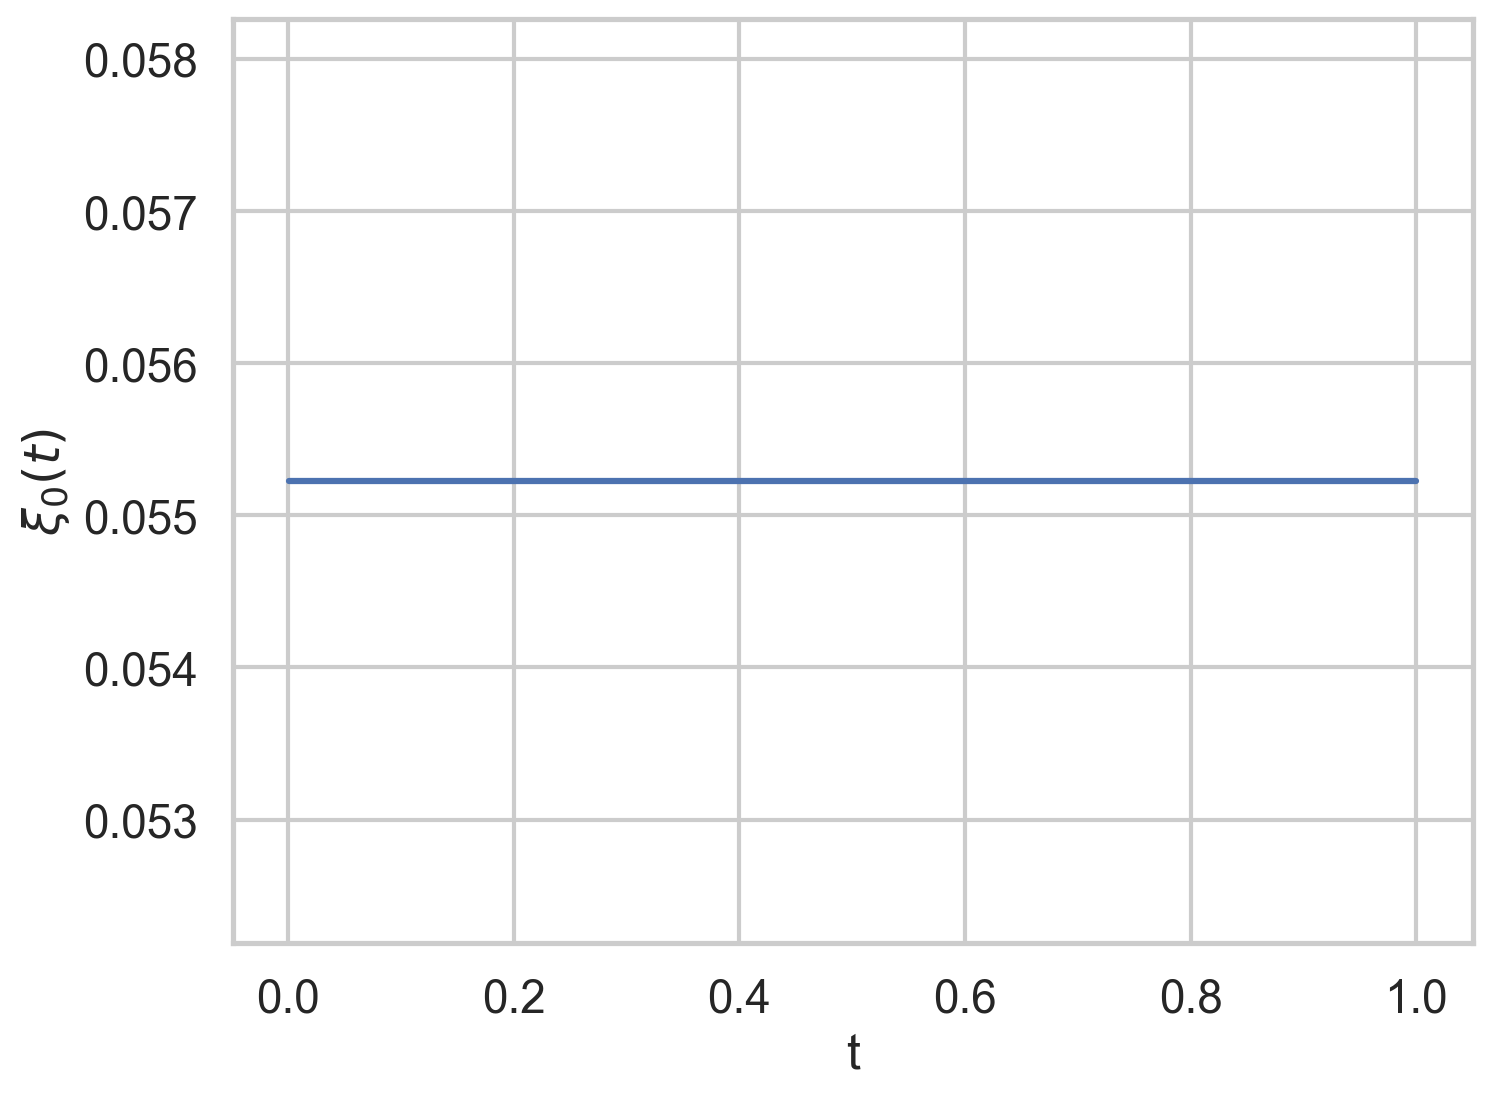

In [13]:
# plot xi0
ts = np.linspace(1e-3, 1.0, 101)
fig, ax = plt.subplots()
ax.plot(ts, onebergomi.xi0(ts))
ax.set_xlabel("t")
ax.set_ylabel(r"$\xi_0(t)$")
plt.show()

In [14]:
# log moneyness
ks = np.linspace(-0.1, 0.5, 11)

In [15]:
# VIX implied volatilities from Monte Carlo
n_quad = 80
impvol_vix = {
    month: onebergomi.implied_vol_vix(k=ks, T=T, n_quad=n_quad)
    for month, T in mats.items()
}

In [16]:
# VIX implied vol from weak approximation
impvol_vix_approx = {
    month: onebergomi.implied_vol_vix_approx(k=ks, T=T, order=3)
    for month, T in mats.items()
}

In [17]:
# VIX implied vol from expansion formula
impvol_vix_expansion = {
    month: onebergomi.implied_vol_vix_expansion(k=ks, T=T, order=1)
    for month, T in mats.items()
}

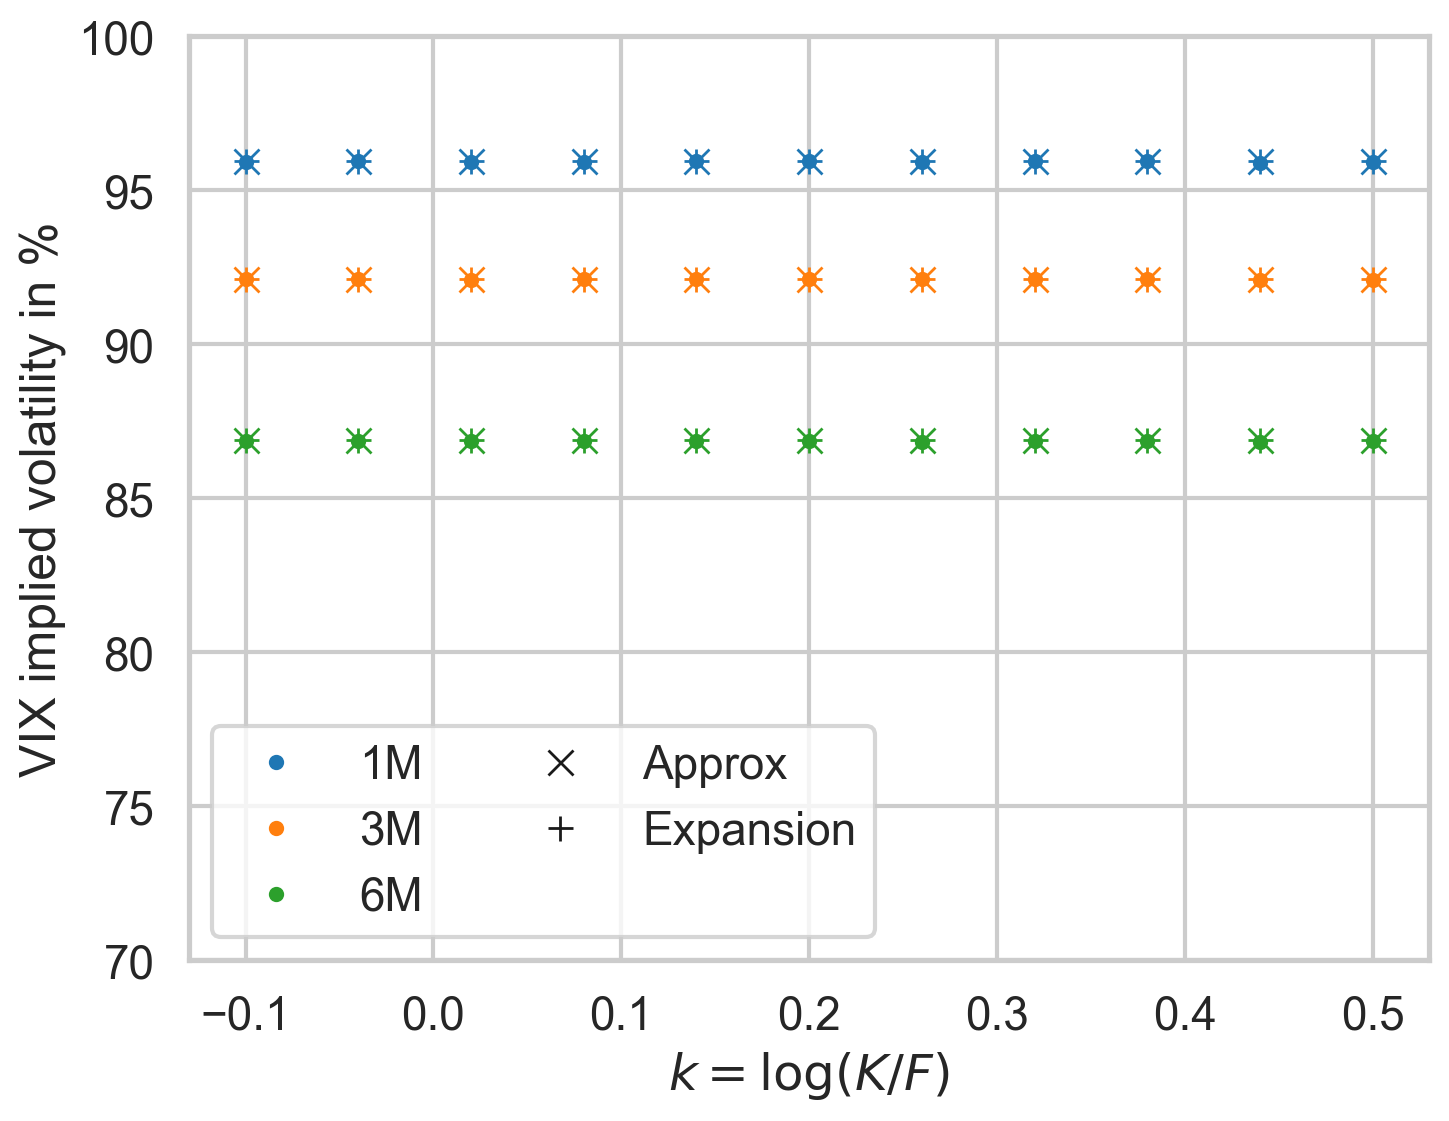

In [22]:
fig, ax = plt.subplots()
for i, month in enumerate(mats.keys()):
    ax.plot(ks, 100 * impvol_vix[month], ".", color=COLORS[i], label=f"{month}")
    ax.plot(ks, 100 * impvol_vix_approx[month], "x", color=COLORS[i])
    ax.plot(ks, 100 * impvol_vix_expansion[month], "+", color=COLORS[i])
ax.plot([], [], "kx", label="Approx")
ax.plot([], [], "k+", label="Expansion")
ax.set_xlabel(r"$k=\log(K/F)$")
ax.set_ylabel("VIX implied volatility in %")
ax.legend(loc="best", ncol=2)
ax.set_ylim(70, 100)
plt.show()

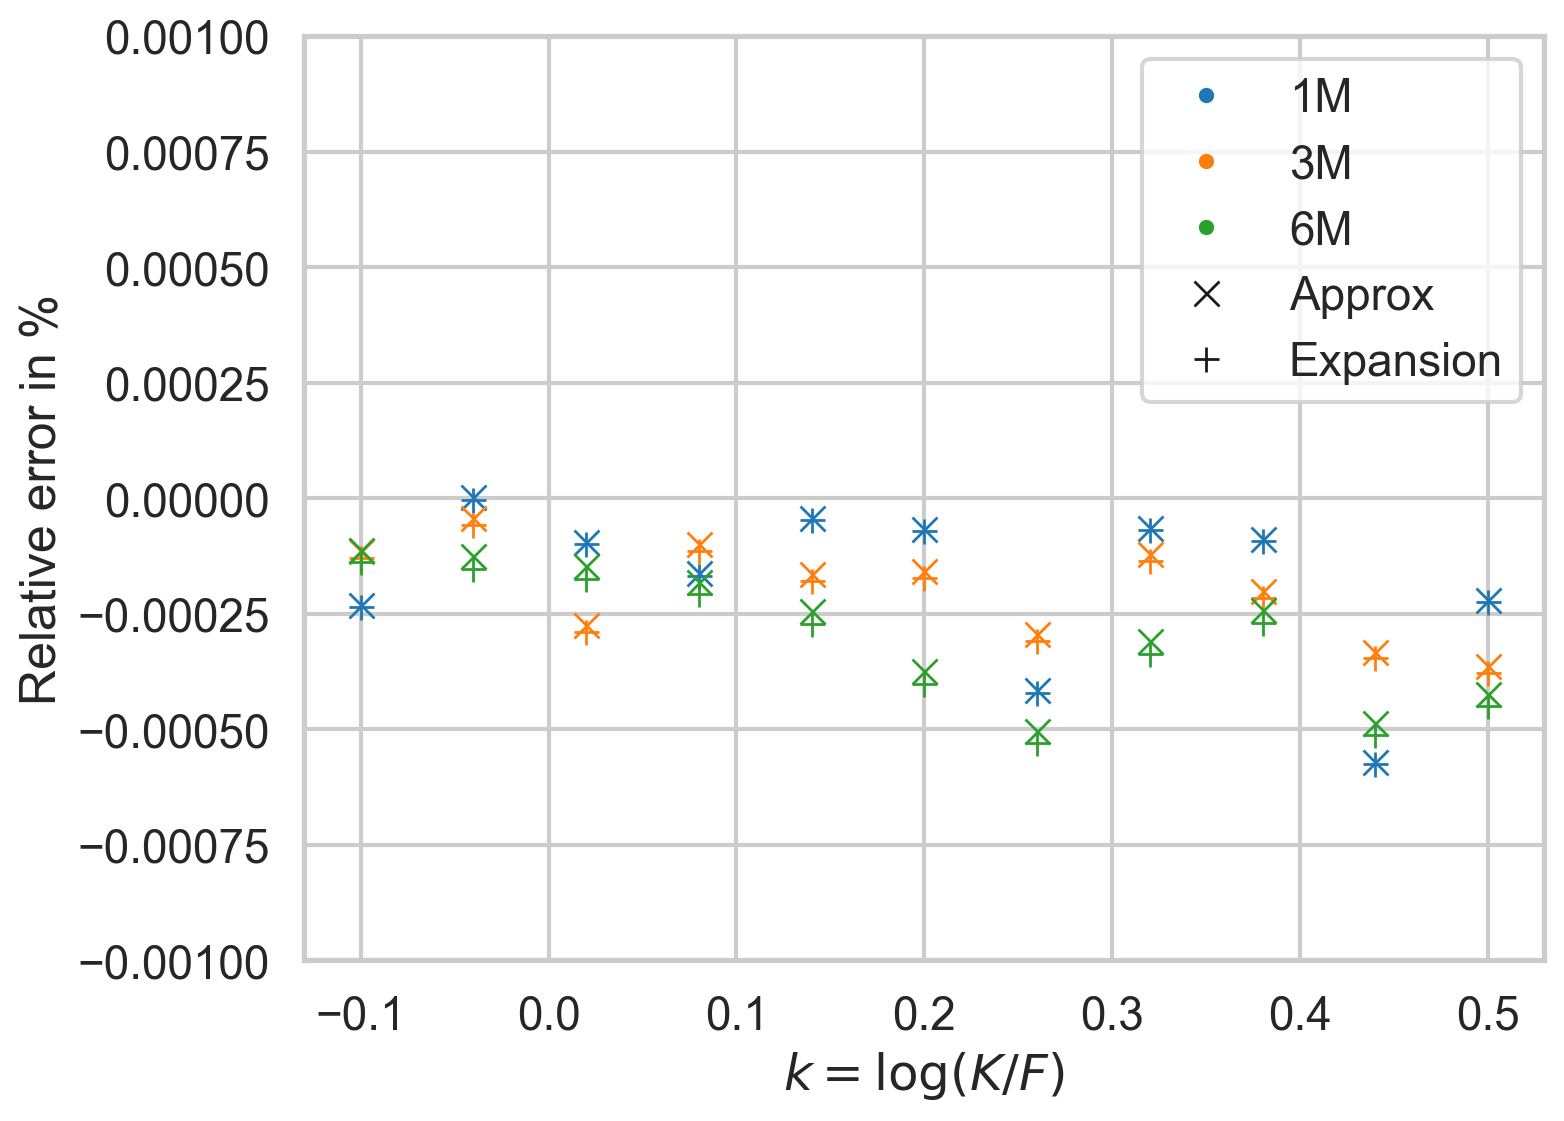

In [23]:
# relative errors
rel_error_approx = [
    relative_error(impvol_vix_approx[month], impvol_vix[month]) for month in mats
]
rel_error_expansion = [
    relative_error(impvol_vix_expansion[month], impvol_vix[month]) for month in mats
]

fig, ax = plt.subplots()
for i, month in enumerate(mats.keys()):
    ax.plot(ks, rel_error_approx[i], "x", color=COLORS[i])
    ax.plot(ks, rel_error_expansion[i], "+", color=COLORS[i])
    ax.plot([], [], ".", color=COLORS[i], label=f"{month}")
ax.plot([], [], "kx", label="Approx")
ax.plot([], [], "k+", label="Expansion")
ax.set_xlabel(r"$k=\log(K/F)$")
ax.set_ylabel("Relative error in %")
ax.legend(loc="best")
ax.set_ylim(-1e-3, 1e-3)
plt.show()

# Mixed case

In [26]:
params = {
    "xi0": lambda u: np.ones_like(u) * 0.235**2,
    "rho": -0.7,
    "w": 2.0,
    "k": 0.5,
}

n_disc = 300
n_mc = 2 * 10**5

OneFactorBergomi(**params)

lbd = 0.3
w_2 = 0.3
ks = ks = np.linspace(-0.1, 0.5, 11)

In [27]:
# VIX implied volatilities from Monte Carlo
n_quad = 80
impvol_vix = {
    month: onebergomi.implied_vol_vix(k=ks, T=T, n_quad=n_quad, lbd=lbd, w_2=w_2)
    for month, T in mats.items()
}

In [28]:
impvol_vix

{'1M': array([0.26812498, 0.2631167 , 0.51691223, 0.49558576, 0.49140465,
        0.49554575, 0.50332028, 0.51364582, 0.52460607, 0.53307731,
        0.54415662]),
 '3M': array([0.17853893, 0.16572677, 0.59648834, 0.55868022, 0.53802602,
        0.5284249 , 0.5260428 , 0.52795805, 0.53244449, 0.53864323,
        0.54585464]),
 '6M': array([0.11224641, 0.09528587, 0.66602213, 0.61284678, 0.57711883,
        0.55461587, 0.54163096, 0.53502949, 0.53267216, 0.53346841,
        0.53585121])}

In [ ]:
# TODO: add implied vol from weak approx / avoid repeating code from rBergomi